# Hierarchical Risk Parity

HRP is a modern portfolio optimization method inspired by machine learning.

The idea is that by examining the hierarchical structure of the market, we can better diversify. 

In this cookbook recipe, we will cover:

- Downloading data for HRP
- Using HRP to find the minimum variance portfolio
- Plotting dendrograms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/PyPortfolio/PyPortfolioOpt/blob/main/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Gradient](https://assets.paperspace.io/img/gradient-badge.svg)](https://console.paperspace.com/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)
    
[![Open In SageMaker Studio Lab](https://studiolab.sagemaker.aws/studiolab.svg)](https://studiolab.sagemaker.aws/import/github/pyportfolio/pyportfolioopt/blob/master/cookbook/5-Hierarchical-Risk-Parity.ipynb)


## Downloading data

HRP only requires historical returns

In [1]:
!pip install pandas numpy matplotlib PyPortfolioOpt
import os
if not os.path.isdir('data'):
    os.system('git clone https://github.com/pyportfolio/pyportfolioopt.git')
    os.chdir('PyPortfolioOpt/cookbook')


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import pypfopt
from pypfopt.data.data_loader import load_stockdata

pypfopt.__version__

'1.6.0'

In [3]:
tickers = ["BLK", "BAC", "AAPL", "TM", "WMT",
           "JD", "INTU", "MA", "UL", "CVS",
           "DIS", "AMD", "NVDA", "PBI", "TGT"]

prices = load_stockdata(tickers=tickers)
prices

,BLK,BAC,AAPL,TM,WMT,JD,INTU,MA,UL,CVS,DIS,AMD,NVDA,PBI,TGT
date,,,,,,,,,,,,,,,
2023-01-03,662.366821,30.974270,123.096024,128.386078,46.147388,53.622425,382.800568,340.245544,50.869663,82.170815,86.923027,64.019997,14.300684,3.534588,135.332779
2023-01-04,671.539062,31.556591,124.365662,127.374069,46.198803,61.492756,383.182220,348.437683,51.212357,81.348312,89.863770,64.660004,14.734251,3.701646,136.215775
2023-01-05,652.320251,31.491892,123.046806,125.823555,46.041336,61.306698,367.573883,345.121613,50.476574,79.995155,89.805138,62.330002,14.250735,3.956629,137.589371
2023-01-06,686.515808,31.806164,127.574219,129.026718,47.169312,59.818222,378.240387,361.306488,51.202274,81.012238,91.759132,63.959999,14.844138,4.044553,142.842834
2023-01-09,700.460022,31.325518,128.095840,129.927307,46.581226,58.729771,387.653748,364.549316,51.353458,80.914940,92.589569,67.239998,15.612370,4.097309,139.453506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-24,1081.050049,50.410000,272.140015,238.639999,126.750000,27.520000,358.709991,498.000000,74.025078,74.180000,106.050003,213.839996,192.850006,10.541825,115.519997
2026-02-25,1093.780029,51.689999,274.230011,241.729996,125.750000,27.540001,381.230011,509.390015,72.645607,76.190002,105.050003,210.860001,195.559998,10.571576,116.440002
2026-02-26,1090.270020,52.299999,272.950012,242.619995,124.419998,26.980000,394.420013,514.770020,72.724998,78.010002,105.550003,203.679993,184.889999,10.760000,114.790001


In [4]:
from pypfopt import expected_returns

rets = expected_returns.returns_from_prices(prices)
rets.tail()

,BLK,BAC,AAPL,TM,WMT,JD,INTU,MA,UL,CVS,DIS,AMD,NVDA,PBI,TGT
date,,,,,,,,,,,,,,,
2026-02-24,0.009374,-0.012923,0.022391,0.002563,0.007472,0.010650,-0.002336,0.003972,0.008245,-0.036623,0.015707,0.087691,0.006787,0.024085,0.019234
2026-02-25,0.011776,0.025392,0.007680,0.012948,-0.007890,0.000727,0.062781,0.022872,-0.018635,0.027096,-0.009430,-0.013936,0.014052,0.002822,0.007964
2026-02-26,-0.003209,0.011801,-0.004668,0.003682,-0.010577,-0.020334,0.034599,0.010562,0.001093,0.023888,0.004760,-0.034051,-0.054561,0.017824,-0.014170
2026-02-27,-0.024801,-0.047227,-0.032130,-0.000989,0.028372,-0.016679,0.037042,0.004740,0.014094,0.024228,0.004642,-0.017036,-0.041646,-0.002788,-0.008712
2026-03-02,0.004778,-0.000401,0.002044,0.005281,-0.006643,-0.006785,0.024521,0.007328,-0.030780,0.022028,-0.016126,-0.007942,0.029855,0.003728,-0.005449


## HRP optimization

HRP uses a completely different backend, so it is currently not possible to pass constraints or specify an objective function.

In [5]:
from pypfopt import HRPOpt

In [6]:
hrp = HRPOpt(rets)
hrp.optimize()
weights = hrp.clean_weights()
weights

OrderedDict([('BLK', 0.04852),
             ('BAC', 0.0402),
             ('AAPL', 0.04647),
             ('TM', 0.05579),
             ('WMT', 0.17428),
             ('JD', 0.02972),
             ('INTU', 0.03761),
             ('MA', 0.08163),
             ('UL', 0.24297),
             ('CVS', 0.08574),
             ('DIS', 0.0481),
             ('AMD', 0.0171),
             ('NVDA', 0.01959),
             ('PBI', 0.01597),
             ('TGT', 0.0563)])

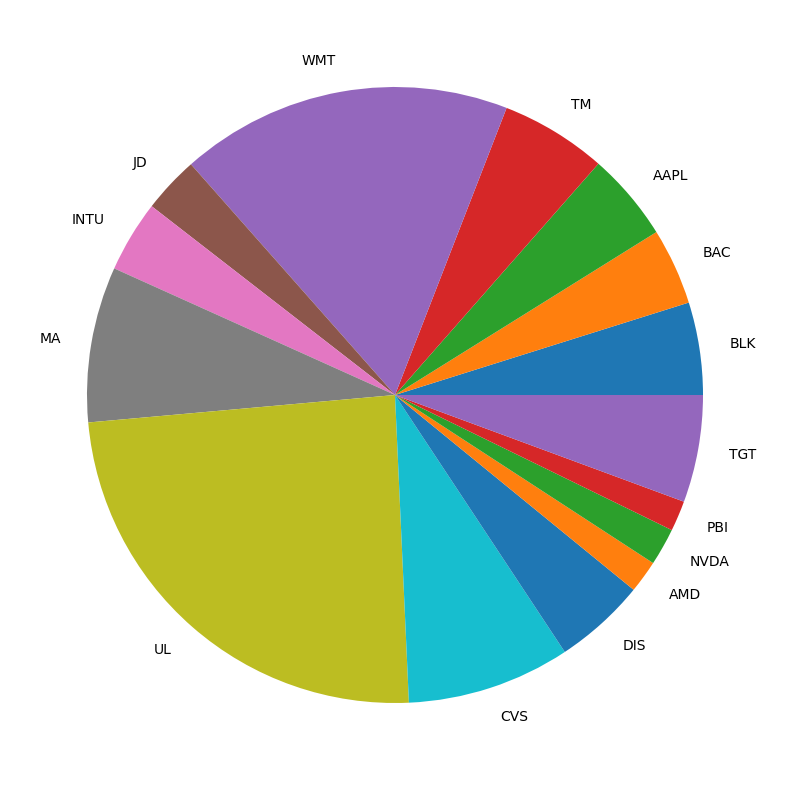

In [7]:
pd.Series(weights).plot.pie(figsize=(10, 10));

In [8]:
hrp.portfolio_performance(verbose=True);

Expected annual return: 18.8%
Annual volatility: 13.0%
Sharpe Ratio: 1.45


## Plotting

It is very simple to plot a dendrogram (tree diagram) based on the hierarchical structure of asset returns

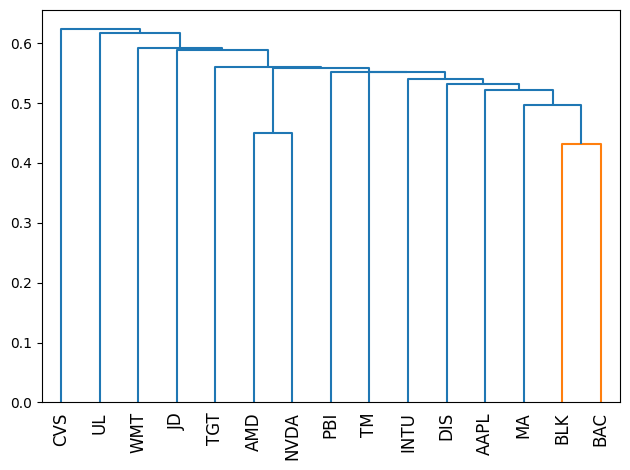

In [9]:
from pypfopt import plotting

plotting.plot_dendrogram(hrp); 

If you look at this dendogram closely, you can see that most of the clusters make a lot of sense. For example, AMD and NVDA (both semiconductor manufacturers) are grouped.